In [10]:
import yfinance as yf
import numpy as np
import pandas as pd
import statsmodels.api as sm
from stocktrends import Renko
import copy

In [ ]:
tickers = ["AAPL", "MSFT"]
ohlc_intraday = {}
ohlc_renko = {}
df = copy.deepcopy(ohlc_intraday)
tickers_signal = {}
tickers_ret = {}

for ticker in tickers:
    temp = yf.download(ticker, period='1mo', interval='1d')
    temp.dropna(how='any', inplace=True)
    temp.columns  = temp.columns.droplevel(1)
    ohlc_intraday[ticker] = temp

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [26]:
def ATR(DF, n=14):
    df = DF.copy()
    df["H-L"] = df["High"] - df["Low"]
    df["H-PC"] = df["High"] - df["Close"].shift(1)
    df["L-PC"] = df["Low"] - df["Close"].shift(1)
    df["TR"] = df[["H-L", "H-PC","L-PC" ]].max(axis=1, skipna=False)
    df["ATR"] = df["TR"].ewm(com=n, min_periods=n).mean()
    return df["ATR"]

def slope(ser, n):
    """Function to calculate the slope of n consecutive points on a plot"""
    slopes = [i*0 for i in range(n-1)]
    for i in range(n, len(ser) + 1):
        y = ser[i-n: i]
        x = np.array(range(n))
        y_scaled = ((y - y.min())/(y.max() - y.min())) 
        x_scaled = ((x - x.min())/(x.max() - x.min()))
        x_scaled = sm.add_constant(x_scaled)
        model = sm.OLS(y_scaled, x_scaled)
        results = model.fit()
        slopes.append(results.params[-1])
    slope_angle = (np.rad2deg(np.arctan(np.array(slopes))))
    return np.array(slope_angle)

def renko_DF(DF):
    """Function to convert ohlc data into renko bricks"""
    df = DF.copy()
    df.reset_index(inplace=True)
    df = df.iloc[:, [0,1,2,3,4,5]]
    df.columns = ["date", "open", "high", "low", "close", "volume"]
    df2 = Renko(df)
    df2.brick_size = max(0.5, round(ATR(DF,120).iloc[-1], 0))
    
    renko_df = df2.get_ohlc_data()
    
    renko_df["bar_num"] = np.where(renko_df["uptrend"] == True, 1, np.where(renko_df["uptrend"] == False, -1, 0)) # noqa: E712

    for i in range(1, len(renko_df)):
        current_val = renko_df.at[i, "bar_num"]
        prev_val = renko_df.at[i-1, "bar_num"]
        
        if current_val > 0 and prev_val > 0:
            renko_df.at[i, "bar_num"] = current_val + prev_val
        elif current_val < 0 and prev_val < 0:
            renko_df.at[i, "bar_num"] = current_val + prev_val
            
    renko_df.drop_duplicates(subset="date", keep="last", inplace=True)
    return renko_df

def OBV(DF):
    """Function to calculate On Balance Volume"""
    df = DF.copy()
    df["daily_ret"] = df["Close"].pct_change()
    df['direction'] = np.where(df["daily_ret"] >=0, 1, -1)
    df['direction'][0]=0
    df["vol_adj"] = df["Volume"] * df["direction"]
    df["obv"] = df["vol_adj"].cumsum()
    return df["obv"]

def CAGR(DF):
    df = DF.copy()
    df["return"] = df["close"].pct_change()
    df["cum_return"] = (1+df["return"]).cumprod()
    n = len(df)/252
    CAGR = (df["cum_return"].iloc[-1])**(1/n) - 1
    return CAGR * 100

def max_drawdown(DF):
    df = DF.copy()
    df["return"] = df["Close"].pct_change()
    df["cum_return"] = (1 + df["return"]).cumprod()
    df["cum_roll_max"] = df["cum_return"].cummax()
    df["drawdown"] = df["cum_roll_max"] - df["cum_return"]
    df["max_drawdown_pct"] = df["drawdown"] / df["cum_roll_max"]
    return df["max_drawdown_pct"].max() * 100

def calmar(DF):
    df = DF.copy()
    return CAGR(df)/max_drawdown(df)

def calculate_volatility(DF):
    df = DF.copy()
    df["return"] = df["Close"].pct_change()
    vol = df["return"].std() * np.sqrt(252)
    return vol * 100

def sharpe_ratio(DF, risk_free_rate=0.03):
    df = DF.copy()
    return (CAGR(df) - risk_free_rate) / calculate_volatility(df)

def sortino_ratio(DF, risk_free_rate=0.03):
    df = DF.copy()
    df.columns = df.columns.droplevel(1)
    df["return"] = df["Close"].pct_change()
    neg_return = np.where(df["return"] > 0, 0, df["return"])
    neg_vol = pd.Series(neg_return[neg_return !=0]).std() * np.sqrt(252)
    cagr = CAGR(df) / 100
    return (cagr - risk_free_rate) / neg_vol

In [23]:

for ticker in tickers:
    print("merging for ", ticker)
    renko = renko_DF(df[ticker])
    df[ticker]["date"] = df[ticker].index
    renko["date"] = pd.to_datetime(renko["date"])
    ohlc_renko[ticker] = df[ticker].merge(renko.loc[:, ["date", "bar_num"]], how='left', on='date')
    ohlc_renko[ticker]["bar_num"].ffill()
    ohlc_renko[ticker]["obv"] = OBV(ohlc_renko[ticker])
    ohlc_renko[ticker]["obv_slope"] = slope(ohlc_renko[ticker]["obv"], 5)
    tickers_signal[ticker] = ""
    tickers_ret[ticker] = []

merging for  AAPL
merging for  MSFT


C:\Users\torre\AppData\Local\Temp\ipykernel_17524\3408265061.py:55: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['direction'][0]=0
C:\Users\torre\AppData\Local\Temp\ipykernel_17524\3408265061.py:55: SettingWithCopyWarning: 
A value is tr

In [24]:
for ticker in tickers: 
    print("calculating daily returns for", ticker)
    for i in range(len(ohlc_renko[ticker])):
        if i == 0:
            tickers_ret[ticker].append(0)
            continue
        if tickers_signal[ticker] == "":
            tickers_ret[ticker].append(0)
            if ohlc_renko[ticker]["bar_num"][i] >=2 and ohlc_renko[ticker]["obv_slope"][i] > 30:
                tickers_signal[ticker] = "Buy"
            elif ohlc_renko[ticker]["bar_num"][i] <= -2 and ohlc_renko[ticker]["obv_slope"][i] <= 30:
                tickers_signal[ticker] = "Sell"
        elif tickers_signal[ticker] == "Buy":
            tickers_ret[ticker].append((ohlc_renko[ticker]["Close"][i]/ohlc_renko[ticker]["Close"][i-1]) - 1)
            if ohlc_renko[ticker]["bar_num"][i]<= -2 and ohlc_renko[ticker]["obv_slope"][i] <= 30:
                tickers_signal[ticker] = "Sell"
            elif ohlc_renko[ticker]["bar_num"][i]<2:
                tickers_signal[ticker] = ""
        elif tickers_signal[ticker] == "Sell":
            tickers_ret[ticker].append((ohlc_renko[ticker]["Close"][i-1]/ohlc_renko[ticker]["Close"][i]) - 1)
            if ohlc_renko[ticker]["bar_num"][i]>=2 and ohlc_renko[ticker]["obv_slope"][i] > 30:
                tickers_signal[ticker] = "Buy"
            elif ohlc_renko[ticker]["bar_num"][i]> -2:
                tickers_signal[ticker] = ""
    ohlc_renko[ticker]["ret"] = np.array(tickers_ret[ticker])

calculating daily returns for AAPL
calculating daily returns for MSFT


<Axes: >

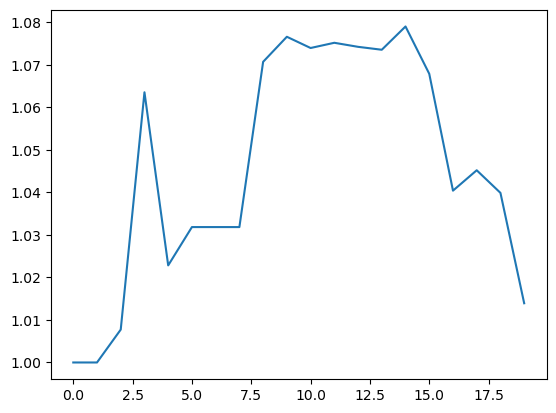

In [31]:
strategy_df = pd.DataFrame()
for ticker in tickers:
    strategy_df[ticker] = ohlc_renko[ticker]["ret"]
    strategy_df["ret"] = strategy_df.mean(axis = 1)
(1+strategy_df["ret"]).cumprod().plot()
